<a href="https://colab.research.google.com/github/Brigiuli/Employee-Attrition-Analysis-Risk-Segmentation-for-Workforce-Retention-Strategy/blob/main/People-Analytics/employee_attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Business Context

El análisis de rotación de empleados (Attrition) tiene como objetivo apoyar a Recursos Humanos en la identificación temprana de empleados con riesgo de salida.

Reducir la rotación permite disminuir costos de contratación, capacitación y pérdida de talento.

Este proyecto busca:
- Identificar factores que influyen en la rotación
- Segmentación de empleados según comportamiento
- Construcción de un modelo predictivo de attrition

## 1. Importación de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
#conectar al drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#cargar la data
df = pd.read_csv("/content/drive/MyDrive/HR-Employee-Attrition.csv")


In [7]:
df.shape
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Análisis y exploración de datos (EDA)

In [8]:
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [11]:
#evaluando cuál de las variables son irrelevantes
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


🔎 Insight:
- El dataset contiene variables demográficas, laborales y de satisfacción del empleado, lo que permite analizar múltiples factores asociados a la rotación.

- La variable objetivo (Attrition) presenta un claro desbalance de clases, con una mayor proporción de empleados que permanecen en la empresa.

#3. Análisis del desequilibrio de clases (diagnóstico del target)

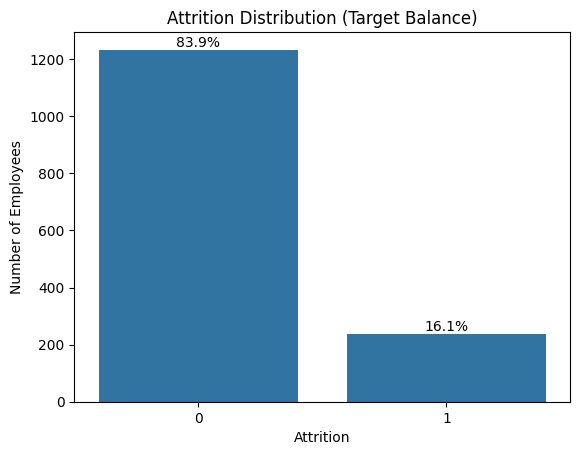

Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64


In [37]:
# vemos cómo está distribuida la variable objetivo
ax = sns.countplot(x='Attrition', data=df)

total = len(df)

# Etiquetas de porcentaje
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Attrition Distribution (Target Balance)')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()

# Proporción exacta (validación)
print(df['Attrition'].value_counts(normalize=True))

🔎 Insight:
Se observa un claro desbalance en la variable objetivo, donde la mayoría de empleados no presentan attrition.  
Este desbalance debe ser considerado en el modelado, ya que puede sesgar el modelo hacia la clase mayoritaria si no se aplican técnicas como SMOTE o ajuste de pesos.

# 4. Business Insights (EDA VISUAL)

##4.1. Análisis de ingresos vs rotación de personal

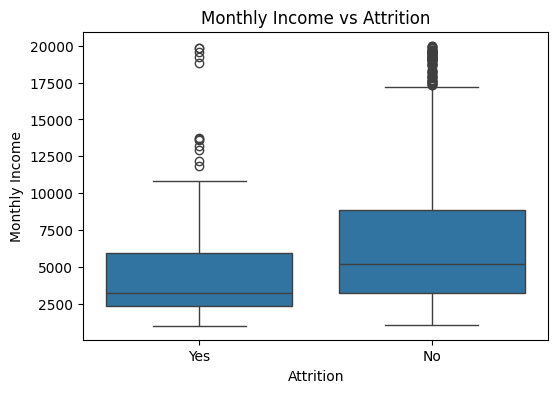

In [15]:
### Monthly Income vs Attrition
### Se analiza si existe diferencia en los niveles de ingreso mensual entre empleados que permanecen y los que abandonan la empresa.

plt.figure(figsize=(6,4))

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')

plt.show()


🔎 Insight:
Se observa que los empleados que abandonan la empresa tienden a tener un menor nivel de ingreso mensual en comparación con aquellos que permanecen.

Esto sugiere que la compensación salarial puede ser un factor relevante en la decisión de renuncia y debería ser considerado dentro de las estrategias de retención.

## 4.2. Análisis del puesto vs rotación de personal

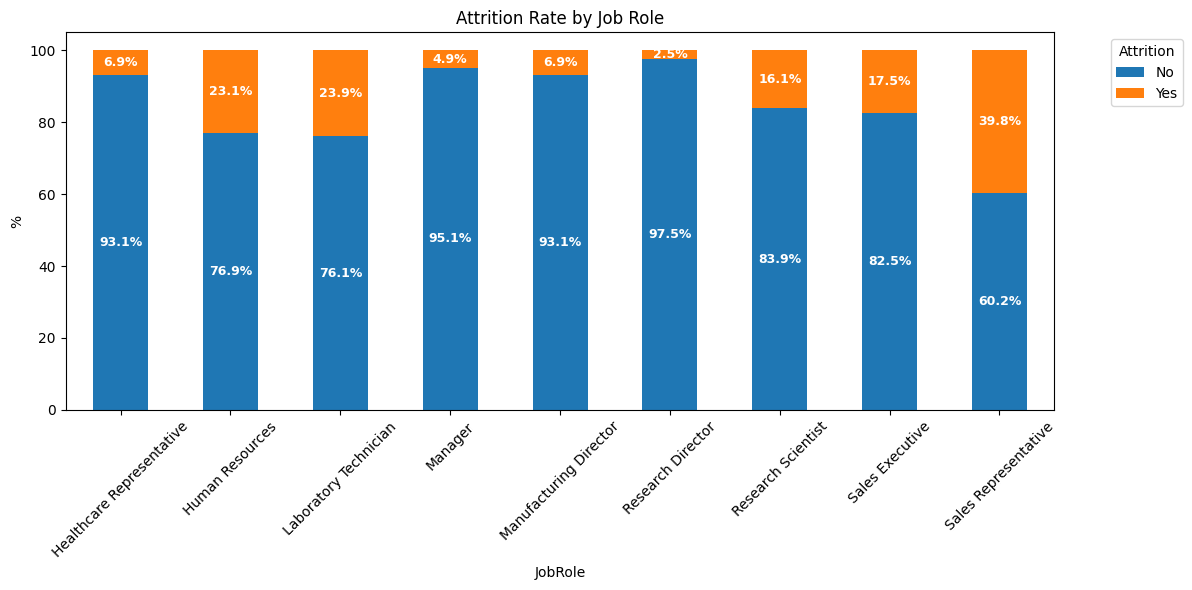

In [16]:
### Attrition by Job Role
### Se analiza la tasa de rotación por rol de trabajo para identificar posiciones con mayor riesgo de salida y posibles áreas críticas para la empresa.

tabla = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100
ax = tabla.plot(kind='bar', stacked=True, figsize=(12,6))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%',
                 label_type='center',
                 color='white',
                 fontsize=9,
                 fontweight='bold')

ax.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.ylabel('%')
plt.xticks(rotation=45)
plt.title('Attrition Rate by Job Role')
plt.tight_layout()
plt.show()

🔎 Insight:

Se observan diferencias significativas en la tasa de rotación según el rol del empleado.

Algunos roles presentan mayor propensión a la salida, lo que sugiere posibles problemas asociados a carga laboral, satisfacción o compensación en posiciones específicas.

Desde una perspectiva de negocio, estos roles deberían ser priorizados en estrategias de retención.

## 4.3. Análisis de horas extras vs rotación de personal

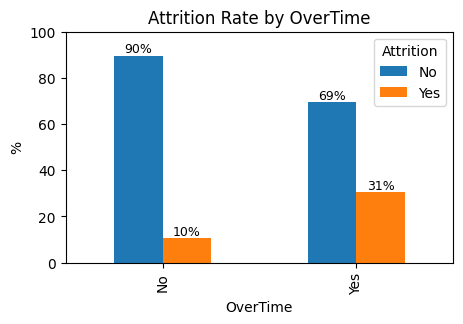

In [17]:
### Attrition vs OverTime
### Se analiza si la realización de horas extras está asociada a una mayor tasa de rotación de empleados.

df_pct = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

ax = df_pct.plot(kind='bar', figsize=(5,3))

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Attrition Rate by OverTime')
plt.ylabel('%')
plt.xlabel('OverTime')
plt.ylim(0,100)
plt.legend(title='Attrition')

plt.show()

🔎 Insight:

Se observa que los empleados que realizan horas extras presentan una mayor tasa de rotación en comparación con aquellos que no realizan overtime.

Esto sugiere que la sobrecarga laboral puede estar asociada al desgaste del empleado y contribuir a la decisión de salida.

Desde el punto de vista de negocio, este hallazgo indica la necesidad de revisar la distribución de carga laboral y políticas de horas extras para mejorar la retención.

#5. Preparación de datos para el modelado

En esta etapa se preparan las variables para el modelado predictivo, eliminando columnas irrelevantes y transformando variables categóricas en formatos numéricos.

Estas transformaciones permiten construir un modelo capaz de identificar patrones asociados a la rotación de empleados.

In [18]:
# Eliminar variables irrelevantes para el análisis
df = df.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1)

# Limpieza de variable objetivo
df['Attrition'] = df['Attrition'].str.strip().str.capitalize()

# Convertir target a variable numérica
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

# Validación de nulos en target
df['Attrition'].isna().sum()

# Encoding de variables categóricas
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Separación de variables predictoras y target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Validación final
y.isna().sum()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalado de variables numéricas
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

🔎 Insight:

Se eliminan variables constantes o irrelevantes que no aportan variabilidad al modelo.

La transformación de variables categóricas permite que el modelo identifique patrones entre características laborales y la probabilidad de rotación.

El escalado asegura que variables con diferentes magnitudes (como income vs age) tengan el mismo peso en el modelo.

# 6. Modelamiento predictivo (regresión lo gística y random forest)


En esta etapa se entrena un modelo inicial utilizando los datos originales, sin aplicar técnicas de balanceo, con el objetivo de establecer una línea base de desempeño.

## 6.1 Modelo base sin balanceo de datos

In [19]:
# Modelo 1: Regresión Logística
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

# Modelo 2: Random Forest
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

# Evaluación
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression
Accuracy: 0.8945578231292517
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.70      0.36      0.47        39

    accuracy                           0.89       294
   macro avg       0.80      0.67      0.71       294
weighted avg       0.88      0.89      0.88       294

Random Forest
Accuracy: 0.8809523809523809
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



🔎 Insight:

Ambos modelos permiten predecir la rotación de empleados con un desempeño razonable.

El Random Forest muestra mejor capacidad predictiva, mientras que la Regresión Logística ofrece mayor interpretabilidad para entender los factores asociados a la rotación.

# 6.2. Manejo del desequilibrio de clases (SMOTE)

El dataset presenta un desbalance significativo en la variable objetivo (Attrition), lo cual puede generar un sesgo del modelo hacia la clase mayoritaria (empleados que permanecen).

Para mitigar este problema y mejorar la capacidad del modelo para identificar empleados en riesgo de rotación, se aplica la técnica SMOTE, la cual genera observaciones sintéticas de la clase minoritaria durante el entrenamiento.

In [20]:
!pip install imbalanced-learn

In [30]:
#crear smote
smote = SMOTE(random_state=42)

# aplicar smote al train (balanceo)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Original distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).value_counts())

Original distribution:
Attrition
0    978
1    198
Name: count, dtype: int64

After SMOTE:
Attrition
0    978
1    978
Name: count, dtype: int64


## 6.3. Modelo mejorado (con smote)

In [31]:
# Reentrenamiento del modelo
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_resampled, y_resampled)

# Predicción
y_pred = model_lr.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7482993197278912
              precision    recall  f1-score   support

           0       0.93      0.77      0.84       255
           1       0.29      0.62      0.39        39

    accuracy                           0.75       294
   macro avg       0.61      0.69      0.62       294
weighted avg       0.84      0.75      0.78       294



🔎 Insight:

Después de aplicar SMOTE, las clases quedan balanceadas, lo que permite al modelo aprender mejor los patrones asociados a empleados que abandonan la empresa.

#6.4. Threshold Optimization (Business Decision)

El threshold define el punto de decisión del modelo para clasificar si un empleado presenta riesgo de rotación.

Su ajuste permite equilibrar el trade-off entre:
- Recall: capacidad del modelo para identificar correctamente a los empleados en riesgo de abandono.
- Precision: capacidad del modelo para minimizar falsas alarmas (empleados clasificados como riesgo cuando no lo son).

In [32]:
y_proba = model_lr.predict_proba(X_test)[:,1]

# Threshold ajustado
y_pred_custom = (y_proba > 0.3).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.93      0.59      0.72       255
           1       0.21      0.72      0.33        39

    accuracy                           0.61       294
   macro avg       0.57      0.66      0.53       294
weighted avg       0.84      0.61      0.67       294



In [34]:
#Probando múltiples threshold para evaluar métricas
from sklearn.metrics import f1_score, recall_score, precision_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_proba > t).astype(int)

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append((t, recall, precision, f1))

df_results = pd.DataFrame(results, columns=['threshold','recall','precision','f1'])
df_results.sort_values(by='f1', ascending=False)

,threshold,recall,precision,f1
13,0.75,0.461538,0.500000,0.480000
11,0.65,0.538462,0.428571,0.477273
10,0.60,0.589744,0.370968,0.455446
12,0.70,0.461538,0.439024,0.450000
9,0.55,0.615385,0.347826,0.444444
14,0.80,0.358974,0.518519,0.424242
7,0.45,0.666667,0.285714,0.400000
8,0.50,0.615385,0.289157,0.393443
15,0.85,0.282051,0.611111,0.385965
6,0.40,0.666667,0.254902,0.368794


🔎 Insight:

Se observa un claro trade-off entre precision y recall al modificar el threshold.

- Threshold bajo → detecta más empleados en riesgo (alto recall), pero genera más falsas alarmas
- Threshold alto → reduce falsas alarmas, pero puede no detectar empleados que realmente se van

Desde una perspectiva de negocio, el threshold óptimo depende del costo de intervención vs el costo de perder talento.

# 7. Evaluación del modelo y análisis del riesgo (RRHH Impact)

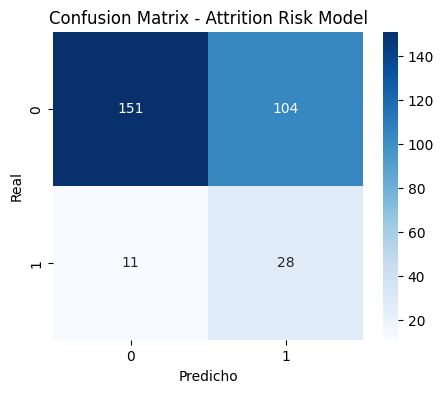

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Confusion Matrix - Attrition Risk Model")

plt.show()

🔎 Insight:

La matriz de confusión permite evaluar los errores del modelo en términos de negocio:

- Falsos negativos: empleados que se van sin ser detectados (riesgo crítico)
- Falsos positivos: empleados identificados como riesgo que realmente no se van (coste de intervención innecesaria)

En este caso, se prioriza reducir falsos negativos, ya que perder talento tiene un mayor impacto que realizar intervenciones preventivas.

## 8. Feature Importance (drivers de negocio)

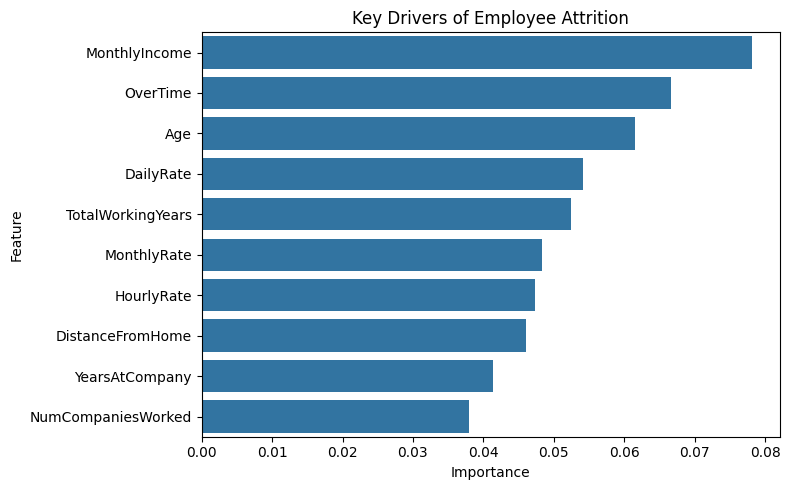

In [36]:
# Feature Importance from Random Forest
importances = model_rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))

plt.title("Key Drivers of Employee Attrition")
plt.tight_layout()
plt.show()

# 9. Conclusiones

El análisis permitió identificar los principales factores asociados a la rotación de empleados y desarrollar un modelo predictivo para estimar el riesgo de attrition.

**Principales hallazgos**
- El ingreso mensual y las horas extras (overtime) se encuentran entre los factores más asociados a la rotación de empleados.
- Se identifican perfiles de mayor riesgo relacionados con baja compensación y alta carga laboral.
- La rotación no ocurre de forma aleatoria, sino que puede explicarse mediante variables laborales y de experiencia.

**Modelo predictivo**
- El modelo permite estimar la probabilidad de salida de un empleado.
- Se aplicó ajuste de threshold para priorizar la detección de empleados en riesgo de rotación.
- El uso de técnicas de balanceo permitió mejorar la capacidad de detección de la clase minoritaria.

**Implicancia de negocio**
- El modelo puede utilizarse como herramienta de apoyo para Recursos Humanos.
- Permite identificar empleados con mayor probabilidad de abandono de manera anticipada.
- Facilita estrategias de retención basadas en datos y priorización de intervenciones sobre perfiles críticos.